In [1]:
# Powtorzenie meta-analizy 22 stacji z 20260717b.ipynb, tym razem na danych
# natywnych 6h (data/csv_data_stations_native6h/, pobranych
# download_stations_native6h.py) zamiast na 2h->6h resamplingu z
# csv_data_allstations/ - patrz 20260719.txt i 20260719a.ipynb za uzasadnienie
# (test zaskoczyl 6.5x roznica PCDF dla Moskwy miedzy tymi zrodlami, mimo
# identycznych parametrow dtype/units - wynikalo to z faktycznej roznicy
# rozdzielczosci: 2h (allstations, mimo nazwy "60min") vs natywne 6h tutaj).
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_mc_parallel

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"
NATIVE6H_DIR = "../data/csv_data_stations_native6h"

# Ta sama lista 22 stacji co w 20260717b.ipynb (>=95% kompletnosci w oknie
# testu, wybrane 2026-07-17), zeby porownanie stary/nowy wynik bylo 1:1.
GOOD_STATIONS = [
    "OULU", "THUL", "LMKS", "APTY", "SOPB", "JUNG1", "SOPO", "FSMT", "MOSC",
    "JUNG", "NEWK", "PWNK", "MXCO", "NAIN", "HRMS", "TERA", "INVK", "ATHN",
    "AATB", "PSNM", "NANM", "MCRL",
]

def load_station_native6h(station):
    path = f"{NATIVE6H_DIR}/{station.lower()}_6h.csv"
    df = pd.read_csv(path, parse_dates=["datetime"])
    return df.set_index("datetime").sort_index()["value"]

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()

eq = load_earthquakes(min_mag=4.0)
cr_by_station = {s: load_station_native6h(s) for s in GOOD_STATIONS}

print(f"EQ (M>=4.0): {len(eq)} zdarzen, {eq.index.min()} .. {eq.index.max()}\n")
print("Sanity check rozdzielczosci (mediana odstepu powinna byc 6h dla kazdej stacji -")
print("jesli nie, to znak ze pojedyncze zapytania NMDB tez cos przycinaja, patrz 20260719.txt):")
for s in GOOD_STATIONS:
    cr = cr_by_station[s]
    delta_median = cr.index.to_series().diff().median()
    flag = "OK" if delta_median == pd.Timedelta(hours=6) else "UWAGA - NIE 6h!"
    print(f"  {s}: {len(cr)} pomiarow, {cr.index.min()} .. {cr.index.max()}, "
          f"mediana odstepu={delta_median} [{flag}]")

EQ (M>=4.0): 290945 zdarzen, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000

Sanity check rozdzielczosci (mediana odstepu powinna byc 6h dla kazdej stacji -
jesli nie, to znak ze pojedyncze zapytania NMDB tez cos przycinaja, patrz 20260719.txt):
  OULU: 13147 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  THUL: 13143 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  LMKS: 13144 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  APTY: 13144 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  SOPB: 13122 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  JUNG1: 13088 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  SOPO: 13089 pomiarow, 2011-01-01 00:00:00 .. 2019-12-31 18:00:00, mediana odstepu=0 days 06:00:00 [OK]
  FSMT: 

In [2]:
# Ten sam test co w 20260716a.ipynb/20260717b.ipynb (kopia funkcji dla
# spojnosci - notebook samodzielny, nie importuje z innych dat).
def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


def full_d_scan(cr, eq, t0, P_days, m, dt_days, d_range):
    return {d: cosmoseismic_stat(cr, eq, t0, P_days, d, m, dt_days)["PCDF"] for d in d_range}


def circular_shift_eq(eq, rng):
    start, end = eq.index.min(), eq.index.max()
    span = end - start
    shift = pd.Timedelta(seconds=int(rng.uniform(0, span.total_seconds())))
    new_idx = (start + ((eq.index - start + shift) % span)).astype(eq.index.dtype)
    return pd.Series(eq.values, index=new_idx).sort_index()


t0 = pd.Timestamp("2013-11-14 07:00:00")  # ten sam t0 co dla Moskwy/Oulu/Auger/20260717b
P_days, m, dt_days = 1675, 4.0, 15

In [3]:
# Deterministyczny skan d=1..30 (bez MC, szybkie) dla wszystkich 22 stacji -
# ranking przed kosztownym MC, bezposrednio porownywalny z tabela z 20260717b.
t_start = time.time()
rows = []
for s in GOOD_STATIONS:
    cr = cr_by_station[s]
    sim = full_d_scan(cr, eq, t0, P_days, m, dt_days, range(1, 31))
    best_d = min(sim, key=sim.get)
    rows.append(dict(station=s, best_d=best_d, best_pcdf=sim[best_d], n_cr=len(cr)))
print(f"Skan 22 stacji w {time.time() - t_start:.1f} s")

ranking = pd.DataFrame(rows).sort_values("best_pcdf")
ranking["sigma_naive"] = norm.isf(ranking["best_pcdf"])  # bez korekty MC/Bonferroniego - tylko ranking
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
print(ranking.to_string(index=False))

Skan 22 stacji w 8.9 s
station  best_d  best_pcdf  n_cr  sigma_naive
   ATHN       3  2.647e-07 12720        5.015
   HRMS       3  4.602e-06 12069        4.435
   NEWK       3   6.83e-06 13045        4.349
   NANM       3  1.039e-05 12570        4.256
   MOSC       5  1.162e-05 13117        4.231
   APTY       3  2.207e-05 13144        4.085
   INVK       3  2.633e-05 12943        4.043
   FSMT       3  4.546e-05 13098        3.914
   OULU       3  4.546e-05 13147        3.914
   SOPO       3  6.455e-05 13089        3.828
   NAIN       3   0.000121 13002        3.671
   THUL       4  0.0001355 13143        3.642
   TERA       3  0.0003132 12928         3.42
   MXCO       3  0.0003279 13017        3.407
   SOPB       3  0.0003354 13122        3.401
   JUNG       3  0.0008134 13115        3.151
   PSNM      14   0.001121 13045        3.056
   MCRL       3   0.001834 12327        2.905
   PWNK       3   0.002403 13043         2.82
   AATB      12   0.003812 12731        2.668
   LMKS    

In [4]:
# Przesiew MC (n_sims=2000) dla wszystkich 22 stacji - REALNE odpalenie (nie
# ma jeszcze zapisanych wynikow dla danych native6h, w przeciwienstwie do
# 20260717b.ipynb ktory wczytywal juz gotowe .npy). To potrwa - w 20260717
# analogiczny przesiew (dane allstations, tez 22 stacje, n=2000) zajal
# 2255.7s (37.6 min) na 20 rdzeniach CPU; dane native6h maja podobny rozmiar
# (podobna liczba wierszy na stacje), wiec podobny czas oczekiwany.
N_SIMS_SCREEN = 2000
screen_rows = []

for row in ranking.itertuples():
    s = row.station
    save_path = f"../results/mc_minima_native6h_{s.lower()}_n{N_SIMS_SCREEN}.npy"

    t_start = time.time()
    mc_minima = run_mc_parallel(
        cr_by_station[s], eq, t0, P_days, m, dt_days, N_SIMS_SCREEN,
        full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
        base_seed=42, save_path=save_path,
    )
    elapsed = time.time() - t_start

    best_pcdf = row.best_pcdf
    p_global = (mc_minima <= best_pcdf).mean()
    n_hits = int((mc_minima <= best_pcdf).sum())
    p_global_floor = max(p_global, 1 / N_SIMS_SCREEN)
    sigma_mc = norm.isf(p_global_floor)

    screen_rows.append(dict(
        station=s, best_d=row.best_d, best_pcdf=best_pcdf,
        n_sims=N_SIMS_SCREEN, n_hits=n_hits, p_global=p_global, sigma_mc=sigma_mc,
    ))
    print(f"{s}: {elapsed:.1f}s, trafien={n_hits}/{N_SIMS_SCREEN}, sigma={sigma_mc:.2f}")

screen_df = pd.DataFrame(screen_rows).sort_values("sigma_mc", ascending=False)
print("\nWyniki przesiewu (n=2000), posortowane:")
print(screen_df.to_string(index=False))

ATHN: 101.2s, trafien=0/2000, sigma=3.29
HRMS: 104.7s, trafien=11/2000, sigma=2.54
NEWK: 102.3s, trafien=4/2000, sigma=2.88
NANM: 104.3s, trafien=8/2000, sigma=2.65
MOSC: 104.6s, trafien=1/2000, sigma=3.29
APTY: 101.7s, trafien=4/2000, sigma=2.88
INVK: 102.7s, trafien=19/2000, sigma=2.35
FSMT: 103.3s, trafien=29/2000, sigma=2.18
OULU: 102.3s, trafien=22/2000, sigma=2.29
SOPO: 102.6s, trafien=23/2000, sigma=2.27
NAIN: 101.6s, trafien=58/2000, sigma=1.90
THUL: 102.5s, trafien=28/2000, sigma=2.20
TERA: 100.9s, trafien=102/2000, sigma=1.64
MXCO: 102.9s, trafien=65/2000, sigma=1.85
SOPB: 103.0s, trafien=81/2000, sigma=1.74
JUNG: 102.8s, trafien=173/2000, sigma=1.36
PSNM: 102.3s, trafien=155/2000, sigma=1.42
MCRL: 103.4s, trafien=84/2000, sigma=1.73
PWNK: 102.2s, trafien=232/2000, sigma=1.20
AATB: 103.4s, trafien=326/2000, sigma=0.98
LMKS: 103.1s, trafien=422/2000, sigma=0.80
JUNG1: 101.8s, trafien=334/2000, sigma=0.97

Wyniki przesiewu (n=2000), posortowane:
station  best_d  best_pcdf  n_si

In [5]:
# Automatyczne dobicie precyzji: dla stacji gdzie blad wzgledny (~1/sqrt(trafien))
# przekracza ~30% (czyli < ~15 trafien przy przesiewie), ekstrapolujemy
# potrzebne n_sims z obserwowanej stopy trafien tak, zeby dostac TARGET_HITS,
# z gornym ograniczeniem MAX_N_REFINE (jak w 20260717b, gdzie ATHN dobito do
# n=75000 - tu bierzemy z zapasem 100000 na wypadek silniejszego/slabszego
# sygnalu niz poprzednio na tych samych stacjach).
TARGET_HITS = 15
MAX_N_REFINE = 100_000
REL_ERR_THRESHOLD = 0.30

refined_sigmas = {}
refined_details = {}

for row in screen_df.itertuples():
    s = row.station
    n_hits_screen = row.n_hits
    rel_err_screen = 1 / np.sqrt(n_hits_screen) if n_hits_screen > 0 else float("inf")
    if rel_err_screen <= REL_ERR_THRESHOLD:
        continue  # juz wystarczajaco precyzyjne przy przesiewie n=2000

    if n_hits_screen == 0:
        n_needed = MAX_N_REFINE
    else:
        rate = n_hits_screen / N_SIMS_SCREEN
        n_needed = min(int(np.ceil(TARGET_HITS / rate)), MAX_N_REFINE)

    best_pcdf = ranking.set_index("station").loc[s, "best_pcdf"]
    save_path = f"../results/mc_minima_native6h_{s.lower()}_n{n_needed}.npy"

    print(f"Dobijanie {s}: n={n_needed} (przesiew mial {n_hits_screen} trafien, blad~{rel_err_screen*100:.0f}%)...")
    t_start = time.time()
    mc_minima = run_mc_parallel(
        cr_by_station[s], eq, t0, P_days, m, dt_days, n_needed,
        full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
        base_seed=42, save_path=save_path,
    )
    elapsed = time.time() - t_start

    p_global = (mc_minima <= best_pcdf).mean()
    p_global_floor = max(p_global, 1 / n_needed)
    sigma_refined = norm.isf(p_global_floor)
    n_hits = int((mc_minima <= best_pcdf).sum())
    rel_err = 1 / np.sqrt(n_hits) if n_hits > 0 else float("nan")

    refined_sigmas[s] = sigma_refined
    refined_details[s] = dict(n_sims=n_needed, n_hits=n_hits, p_global=p_global,
                               sigma=sigma_refined, rel_err=rel_err)
    print(f"  {s}: {elapsed:.1f}s, trafien={n_hits}, sigma={sigma_refined:.2f}, blad~{rel_err*100:.0f}%")

if not refined_sigmas:
    print("Zadna stacja nie wymagala dobicia - wszystkie mialy blad <=30% juz przy przesiewie n=2000.")

Dobijanie ATHN: n=100000 (przesiew mial 0 trafien, blad~inf%)...
  ATHN: 5022.5s, trafien=23, sigma=3.50, blad~21%
Dobijanie MOSC: n=30000 (przesiew mial 1 trafien, blad~100%)...
  MOSC: 1506.4s, trafien=23, sigma=3.17, blad~21%
Dobijanie APTY: n=7500 (przesiew mial 4 trafien, blad~50%)...
  APTY: 379.0s, trafien=15, sigma=2.88, blad~26%
Dobijanie NEWK: n=7500 (przesiew mial 4 trafien, blad~50%)...
  NEWK: 381.4s, trafien=12, sigma=2.95, blad~29%
Dobijanie NANM: n=3750 (przesiew mial 8 trafien, blad~35%)...
  NANM: 192.8s, trafien=13, sigma=2.70, blad~28%
Dobijanie HRMS: n=2728 (przesiew mial 11 trafien, blad~30%)...
  HRMS: 140.5s, trafien=13, sigma=2.59, blad~28%


In [6]:
# Finalna tabela + porownanie ze starym wynikiem (20260717b.ipynb, dane
# allstations 2h->6h resample) - liczby z dziennika 20260717.txt wpisane
# na sztywno jako punkt odniesienia (nie przeliczamy ich od nowa, to juz
# ustalone, zapisane wyniki poprzedniej sesji).
OLD_SIGMAS_ALLSTATIONS = {
    "ATHN": 3.392, "NEWK": 3.004, "APTY": 2.878, "NANM": 2.7, "HRMS": 2.484,
    "MOSC": 2.484, "INVK": 2.346, "OULU": 2.257, "SOPO": 2.241, "THUL": 2.197,
    "FSMT": 2.183, "MXCO": 1.919, "NAIN": 1.896, "MCRL": 1.896, "SOPB": 1.745,
    "PSNM": 1.476, "TERA": 1.402, "JUNG": 1.379, "PWNK": 1.19, "AATB": 0.9842,
    "JUNG1": 0.9721, "LMKS": 0.6855,
}

sigmas_new = screen_df.set_index("station")["sigma_mc"].copy()
sigmas_new.update(pd.Series(refined_sigmas))

final_table = pd.DataFrame({
    "sigma_old_allstations": pd.Series(OLD_SIGMAS_ALLSTATIONS),
    "sigma_new_native6h": sigmas_new,
})
final_table["delta"] = final_table["sigma_new_native6h"] - final_table["sigma_old_allstations"]
final_table["dobite"] = final_table.index.isin(refined_sigmas)
final_table = final_table.sort_values("sigma_new_native6h", ascending=False)

print("Porownanie stary (allstations 2h->6h) vs nowy (natywne 6h) wynik, per stacja:")
print(final_table.to_string())
print(f"\nSrednia zmiana sigma (nowe - stare): {final_table['delta'].mean():+.3f}")
print(f"Ile stacji poprawilo sie (nowe > stare): {(final_table['delta'] > 0).sum()} / {len(final_table)}")

Porownanie stary (allstations 2h->6h) vs nowy (natywne 6h) wynik, per stacja:
       sigma_old_allstations  sigma_new_native6h      delta  dobite
ATHN                   3.392               3.503      0.111    True
MOSC                   2.484               3.168     0.6843    True
NEWK                   3.004               2.948   -0.05616    True
APTY                   2.878               2.878  0.0001617    True
NANM                     2.7                 2.7  2.947e-05    True
HRMS                   2.484               2.592     0.1084    True
INVK                   2.346               2.346  -0.000469   False
OULU                   2.257                2.29    0.03337   False
SOPO                   2.241               2.273    0.03243   False
THUL                   2.197               2.197  0.0002864   False
FSMT                   2.183               2.183  0.0004865   False
NAIN                   1.896               1.896 -0.0003021   False
MXCO                   1.919          

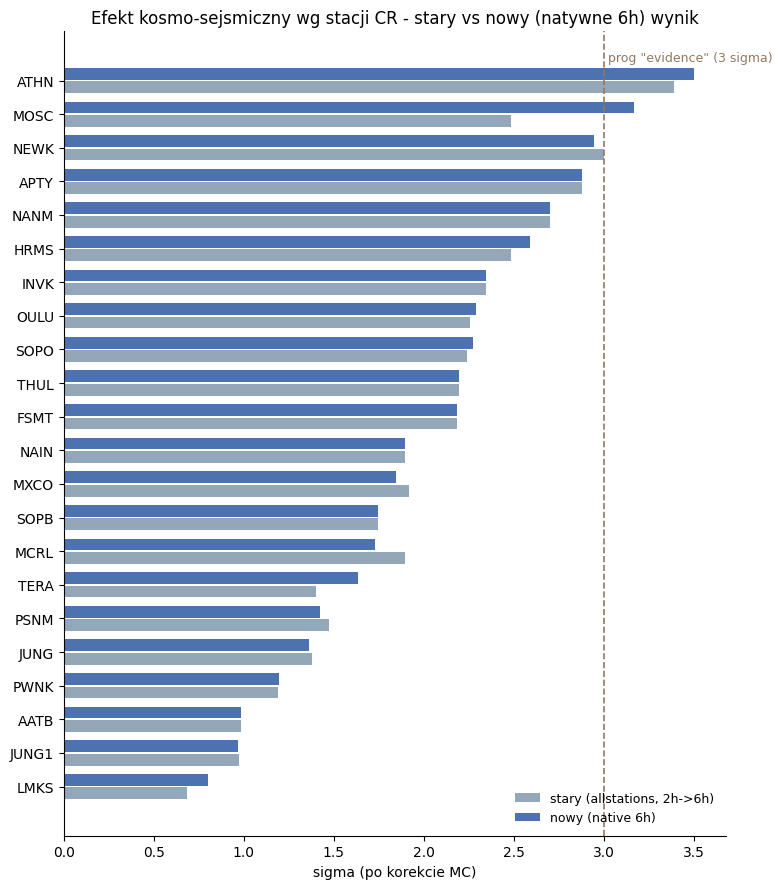

In [7]:
# Wizualizacja: stary (allstations) vs nowy (native6h) wynik obok siebie,
# posortowane po nowym sigma, z progiem "evidence" (3 sigma).
plot_df = final_table.sort_values("sigma_new_native6h")
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(y - 0.2, plot_df["sigma_old_allstations"], height=0.35, color="#94A7B8", label="stary (allstations, 2h->6h)")
ax.barh(y + 0.2, plot_df["sigma_new_native6h"], height=0.35, color="#4C72B0", label="nowy (native 6h)")
ax.axvline(3.0, color="#937860", linewidth=1.2, linestyle="--")
ax.text(3.0, len(plot_df) - 0.5, ' prog "evidence" (3 sigma)', va="bottom", ha="left", color="#937860", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("sigma (po korekcie MC)")
ax.set_title("Efekt kosmo-sejsmiczny wg stacji CR - stary vs nowy (natywne 6h) wynik")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

In [8]:
# Meta-analiza (jak w 20260717b) na nowych, natywnych danych: korelacja
# miedzy stacjami + Stouffer skorygowany na korelacje.
window_mask_fn = lambda s: cr_by_station[s][(cr_by_station[s].index >= t0) & (cr_by_station[s].index <= t0 + pd.Timedelta(days=P_days))]
cr_matrix = pd.DataFrame({s: window_mask_fn(s) for s in GOOD_STATIONS})
corr = cr_matrix.corr()
pairwise = corr.where(~np.eye(len(corr), dtype=bool)).stack()
print(f"Korelacja parami CR (native6h, w oknie t0): mediana={pairwise.median():.3f}, "
      f"min={pairwise.min():.3f}, max={pairwise.max():.3f}")
print("(dla porownania, dane allstations z 20260717: mediana=0.875, rho_mean=0.843)")

k = len(GOOD_STATIONS)
rho_mean = pairwise.mean()
k_eff = k / (1 + (k - 1) * rho_mean)
print(f"\nk={k} stacji nominalnie, rho_mean={rho_mean:.3f} -> k_eff~={k_eff:.1f} efektywnie niezaleznych")

Z_sum = sigmas_new.sum()
var_corr = k + k * (k - 1) * rho_mean
Z_corrected = Z_sum / np.sqrt(var_corr)
p_corrected = norm.sf(Z_corrected)
print(f"\nStouffer Z skorygowany (nowe dane, native6h): Z={Z_corrected:.2f}, "
      f"p={p_corrected:.3e} ({norm.isf(p_corrected):.2f} sigma)")
print(f"(dla porownania, stary wynik z 20260717 na danych allstations: 2.15 sigma)")

Korelacja parami CR (native6h, w oknie t0): mediana=0.875, min=0.367, max=0.992
(dla porownania, dane allstations z 20260717: mediana=0.875, rho_mean=0.843)

k=22 stacji nominalnie, rho_mean=0.829 -> k_eff~=1.2 efektywnie niezaleznych

Stouffer Z skorygowany (nowe dane, native6h): Z=2.22, p=1.322e-02 (2.22 sigma)
(dla porownania, stary wynik z 20260717 na danych allstations: 2.15 sigma)
